In [1]:
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import numpy as np
import matplotlib.pyplot as plt

In [2]:
if torch.cuda.is_available():
    dev = "cuda:0"
elif torch.backends.mps.is_available():
    dev = "mps"
else:
    dev = "cpu"
device = torch.device(dev)
device

device(type='mps')

In [3]:
device = torch.device("cpu")
device

device(type='cpu')

In [4]:
learning_rate = 1e-2
gamma = 0.99  # Discount factor
num_episodes = 1000
hidden_size = 128

In [5]:
class PolicyNetwork(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return torch.softmax(x, dim=-1)

In [6]:
class REINFORCEAgent:
    def __init__(self, obs_size, n_actions, hidden_size=128, lr=1e-2, gamma=0.99):
        self.policy = PolicyNetwork(obs_size, hidden_size, n_actions)
        self.optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.gamma = gamma
        self.log_probs = []
        self.rewards = []

    def select_action(self, state, inference=False):
        state = torch.tensor(state, dtype=torch.float32)
        probs = self.policy(state)
        dist = Categorical(probs)
        if inference:
            action = torch.argmax(probs)
        else:
            action = dist.sample()
        self.log_probs.append(dist.log_prob(action))
        return action.item()

    def store_reward(self, reward):
        self.rewards.append(reward)

    def update(self):
        returns = []
        R = 0
        for r in reversed(self.rewards):
            R = r + self.gamma * R
            returns.insert(0, R)

        returns = torch.tensor(returns)
        returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        loss = -torch.sum(torch.stack(self.log_probs) * returns)

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.log_probs = []
        self.rewards = []

In [7]:
env = gym.make("CartPole-v1")

obs_size = env.observation_space.shape[0]
n_actions = env.action_space.n

agent = REINFORCEAgent(obs_size, n_actions)

episode_rewards = []

best_avg_reward = -float('inf')  # track best moving average
window = 20  # moving average window

for episode in range(num_episodes):
    state, _ = env.reset()
    done = False
    total_reward = 0

    while not done:
        action = agent.select_action(state)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        agent.store_reward(reward)
        total_reward += reward

    agent.update()

    if episode % 50 == 0:
        print(f"Episode {episode}, reward: {total_reward}")

    episode_rewards.append(total_reward)

    # Compute moving average
    if len(episode_rewards) >= window:
        moving_avg = np.mean(episode_rewards[-window:])
        # Save best network based on moving average
        if moving_avg > best_avg_reward:
            best_avg_reward = moving_avg
            torch.save(agent.policy.state_dict(), "best_pg.pth")

    print(f"Episode {episode} | Reward: {total_reward} | Moving Avg: {moving_avg if len(episode_rewards) >= window else total_reward:.2f}")

env.close()

Episode 0, reward: 14.0
Episode 0 | Reward: 14.0 | Moving Avg: 14.00
Episode 1 | Reward: 18.0 | Moving Avg: 18.00
Episode 2 | Reward: 21.0 | Moving Avg: 21.00
Episode 3 | Reward: 62.0 | Moving Avg: 62.00
Episode 4 | Reward: 16.0 | Moving Avg: 16.00
Episode 5 | Reward: 18.0 | Moving Avg: 18.00
Episode 6 | Reward: 115.0 | Moving Avg: 115.00
Episode 7 | Reward: 22.0 | Moving Avg: 22.00
Episode 8 | Reward: 20.0 | Moving Avg: 20.00
Episode 9 | Reward: 36.0 | Moving Avg: 36.00
Episode 10 | Reward: 22.0 | Moving Avg: 22.00
Episode 11 | Reward: 41.0 | Moving Avg: 41.00
Episode 12 | Reward: 27.0 | Moving Avg: 27.00
Episode 13 | Reward: 48.0 | Moving Avg: 48.00
Episode 14 | Reward: 42.0 | Moving Avg: 42.00
Episode 15 | Reward: 79.0 | Moving Avg: 79.00
Episode 16 | Reward: 25.0 | Moving Avg: 25.00
Episode 17 | Reward: 15.0 | Moving Avg: 15.00
Episode 18 | Reward: 32.0 | Moving Avg: 32.00
Episode 19 | Reward: 45.0 | Moving Avg: 35.90
Episode 20 | Reward: 13.0 | Moving Avg: 35.85
Episode 21 | Rewar

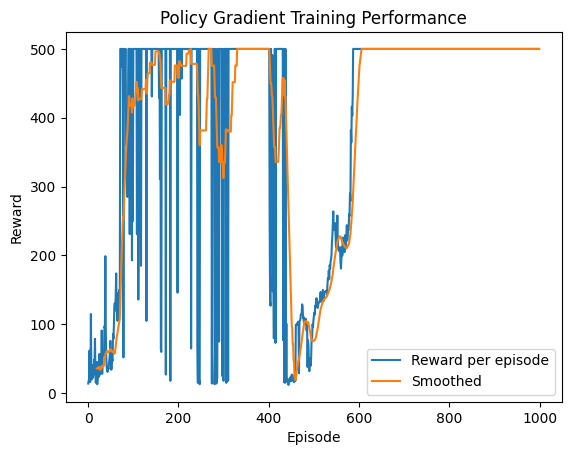

In [8]:
plt.plot(episode_rewards, label="Reward per episode")

# Optional smoothing
window = 20
smoothed = np.convolve(
    episode_rewards,
    np.ones(window)/window,
    mode='valid'
)
plt.plot(range(window-1, len(episode_rewards)), smoothed, label="Smoothed")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Policy Gradient Training Performance")
plt.legend()
plt.show()

In [9]:
agent.policy.load_state_dict(torch.load("best_pg.pth"))
agent.epsilon = 0.0  # no exploration

In [10]:
num_eval_episodes = 100
episode_lengths = []

for episode in range(num_eval_episodes):
    state, _ = env.reset()
    done = False
    steps = 0

    while not done:
        action = agent.select_action(state, inference=True)
        state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        steps += 1

    episode_lengths.append(steps)

env.close()

average_steps = sum(episode_lengths) / num_eval_episodes
print(f"Average steps over {num_eval_episodes} episodes: {average_steps:.2f}")

Average steps over 100 episodes: 500.00


In [11]:
env = gym.make("CartPole-v1", render_mode="human")

state, _ = env.reset()
done = False

while not done:
    action = agent.select_action(state)
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated

env.close()

/Users/wick/reinforcement_learning/.venv/lib/python3.13/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists
